## **The Eady Problem**

the "Eady Problem" is a model for baroclinic instability. We start with several assumptions.

1. The motion is on the f-plane ($\beta =0$) so there is a constant coriolis parameter. 
2. The fluid is uniformly stratified
3. The basic state has constant shear, $U_o(z) = \Lambda z / H $ where $ \Lambda $ is the constant shear, $U$ is the zonal velocity, and $H$ is the vertical extent. 
4. The model is bounded by two flat layers or "rigid lids" at $z=0$ and $z=H$

### **The Geostrophic Basic State**

the geostrophic basic state in the Eady problem is represented by the streamfunction
$\psi(y,z) = - \Lambda z y $.

the potential vorticity in the geostrophic basic state is equal to 0. 

### **Problem Parameters**

coriolis parameter : $f = 10^{-4}$ s $^{-1}$

buoyancy frequency (square root of $\partial_z B$) : $N = 10^{-2}$ s $^{-1} $

Zonal Velocity : $U = 0.1 $ m/s

Vertical Depth : $H = 1$ km

Deformation Radius : $L_d = NH/f = 100 $ km

Scale of Max Instability : $L_{max} = 3.9 L_d = 400 $ km

Growth Rate : $\sigma = 0.3 U/L_d = 0.026 $ per day


### Refer to Eady.jl, where the simulation code is written. 

We have periodic boundary in the x and bounded walls both in the y and z. 
We also have no slip conditions on velocity in the y and z. 

In [1]:
using Oceananigans
using Printf
using Oceananigans.Utils
using Oceananigans.Coriolis
using Oceananigans.OutputWriters
using Oceananigans.Units
using Oceananigans.Grids: Center
using NCDatasets
using CairoMakie
using Statistics

In [2]:
ds_b = NCDataset(string("/Users/hfdrake/Documents/GFD_Fall25/output/buoy_vort40day.nc"))
ds_v = NCDataset(string("/Users/hfdrake/Documents/GFD_Fall25/output/velocities40day.nc"));

In [20]:
b = ds_b["b"][:,:,:,:];
x = ds_b["x_caa"][:]
y = ds_b["y_aca"][:]
z = ds_b["z_aac"][:];
ζ = ds_b["ζ"][:,:,:,:]


Nx = ds_b.attrib["Nx"]
Ny = ds_b.attrib["Ny"]
Nz = ds_b.attrib["Nz"]

Lx = ds_b.attrib["Lx"]
Ly = ds_b.attrib["Ly"]
H = ds_b.attrib["H"]

f_0 = ds_b.attrib["f₀"]
N = ds_b.attrib["N"]
U_shear = ds_b.attrib["U_shear"]

Ld = N * H / f_0
σ_t = 0.3 * U_shear / Ld

time = ds_b["time"][:]

sec_2_day = (1/24) * (1/60) * (1/60);

print(σ_t/ sec_2_day)

0.6480000000000001

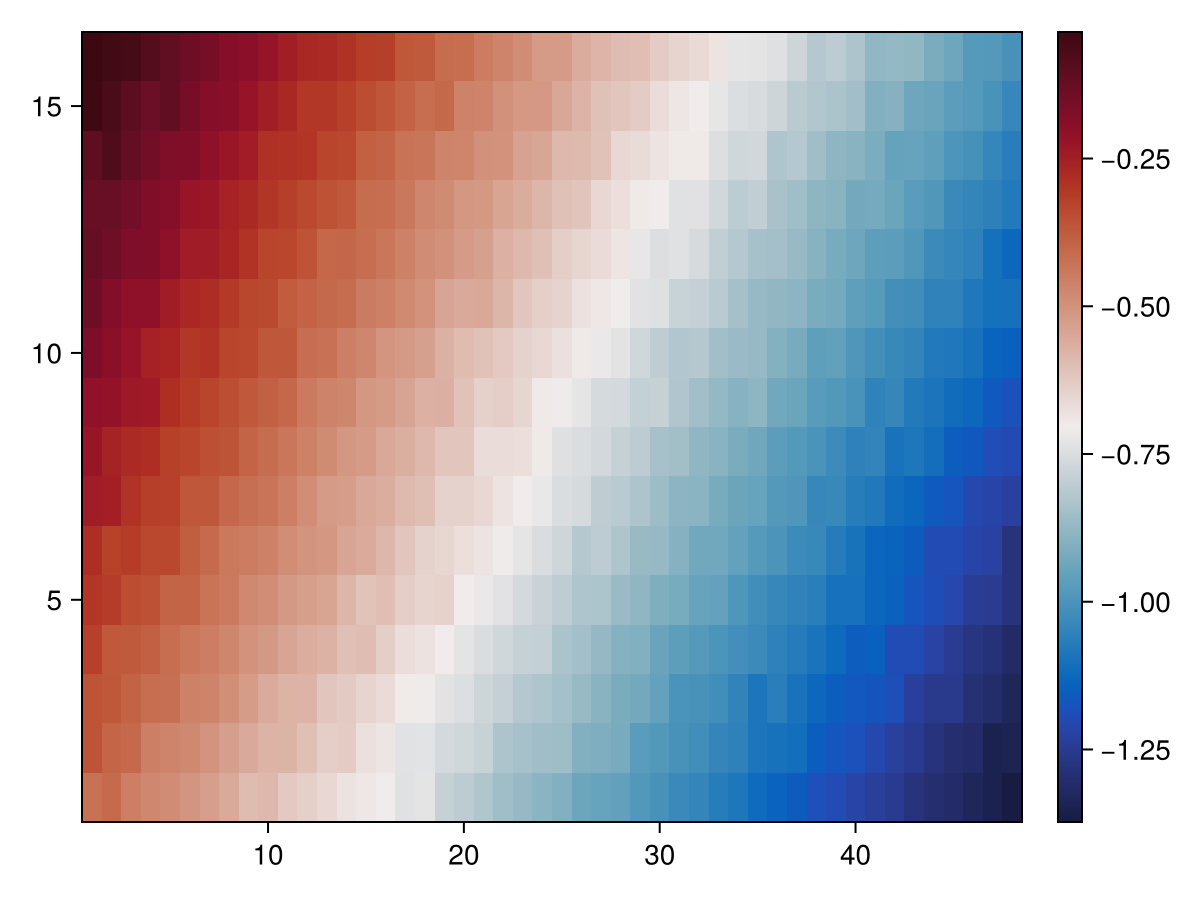

In [4]:
#initial buoyancy state in the y-z plane
f = Figure()
ax = Axis(f[1,1])
hm = heatmap!(b[Int(Nx/2),:, :, 1], colormap=:balance)
Colorbar(f[1,2], hm)

f

In [6]:
#lets compute the EKE, for this we need the perturbation velocities
# so from the velocity fields we need to subtract out the background fields
# only the x velocity (u) has a background component so we just need to subtract that

u = ds_v["u"][:,:,:,:] #(48,48,16,81)
v = ds_v["v"][:,:,:,:] #(48,49,16,81)
w = ds_v["w"][:,:,:,:] #(48,48,17,81)

Λ = U_shear / H
U_bg = zeros(size(u))

# Interpolate v from faces to centers in y-direction 
v_center = 0.5 .* (v[:, 1:end-1, :, :] .+ v[:, 2:end, :, :])
w_center = 0.5 .* (w[:, :, 1:end-1, :] .+ w[:, :, 2:end, :])

println("u shape: ", size(u))
println("v_center shape: ", size(v_center))
println("w_center shape: ", size(w_center))

for k in 1:Nz
    U_bg[:,:,k,:] .= Λ .* z[k]
end

u_prime = u .- U_bg
v_prime = v_center
w_prime = w_center

EKE = 0.5 .* (u_prime.^2 .+ v_prime.^2 .+ w_prime.^2 );

println("EKE shape: ", size(EKE))
println("Max EKE: ", maximum(EKE))

u shape: (48, 48, 16, 161)
v_center shape: (48, 48, 16, 161)
w_center shape: (48, 48, 16, 161)
EKE shape: (48, 48, 16, 161)
Max EKE: 1389.7575012120749


### now we want to compute the volume averaged EKE so we can plot it as a function of time

$$ \langle EKE(t) \rangle = \frac{1}{V} \int \int \int EKE(x,y,z,t) dV $$

In [7]:
V = Lx * Ly * H

dx = Lx / Nx
dy = Ly / Ny
dz = H / Nz
dV = dx * dy * dz

EKE_avg = zeros(size(time))
for t in 1:length(time)
    EKE_avg[t] = sum(EKE[:, :, :, t]) .* dV / V
end

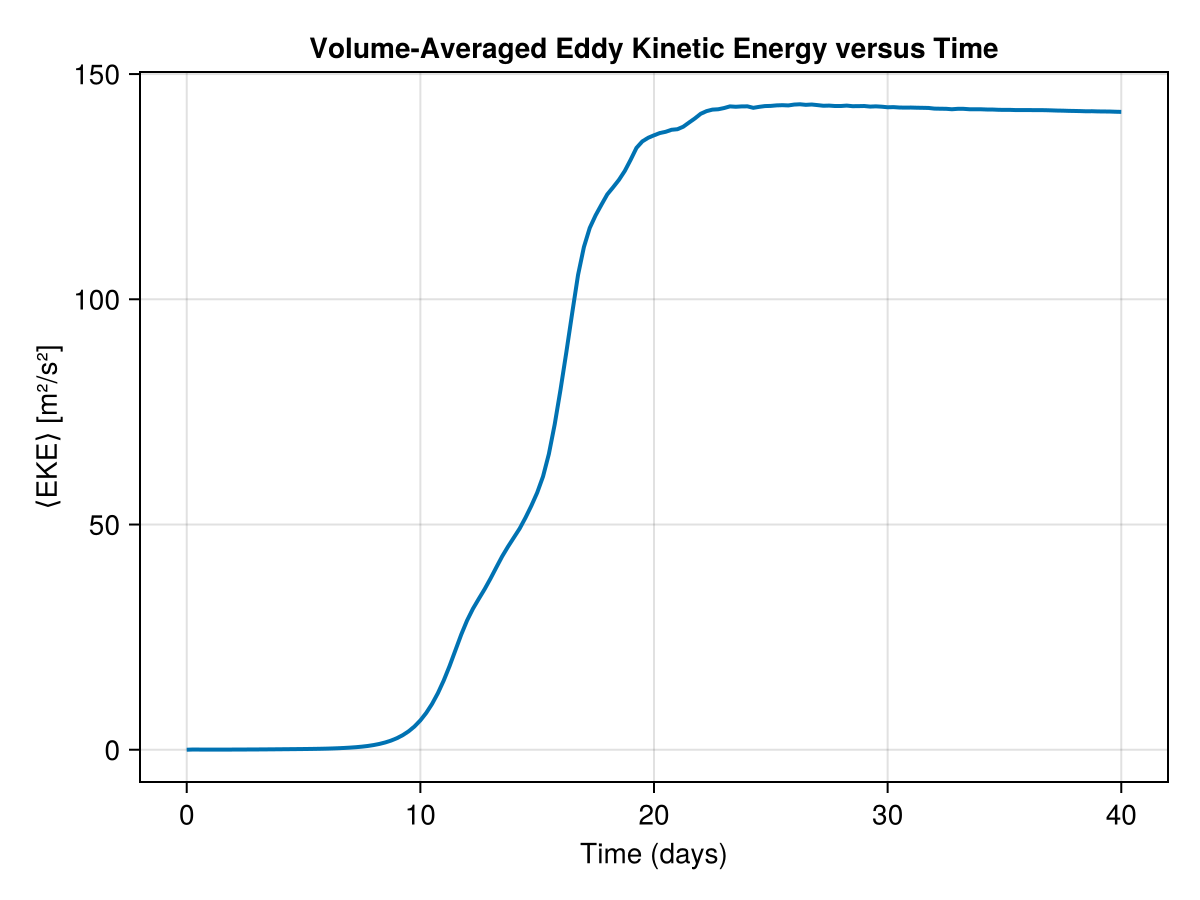

In [8]:
fig = Figure()
ax = Axis(fig[1,1], 
            xlabel = "Time (days)", 
            ylabel = "⟨EKE⟩ [m²/s²]", 
            title = "Volume-Averaged Eddy Kinetic Energy versus Time")

lines!(ax, time .* sec_2_day, (EKE_avg), linewidth=2)

fig

So this figure is showing the three phases of baroclinic instability:
1. early linear growth:
     since the initial perturbation is tiny, 1e-2 in our case, the EKE stays small for a long time. this occurs from days 0-10

2. then we have the rapid exponential growth phase 
     this is the dominant growing eady mode occurs days 10-20

3. then we have saturation
    EKE stops growing once the shear is consumed and the eddies equilbrate


below i'll include the natural log of the plot

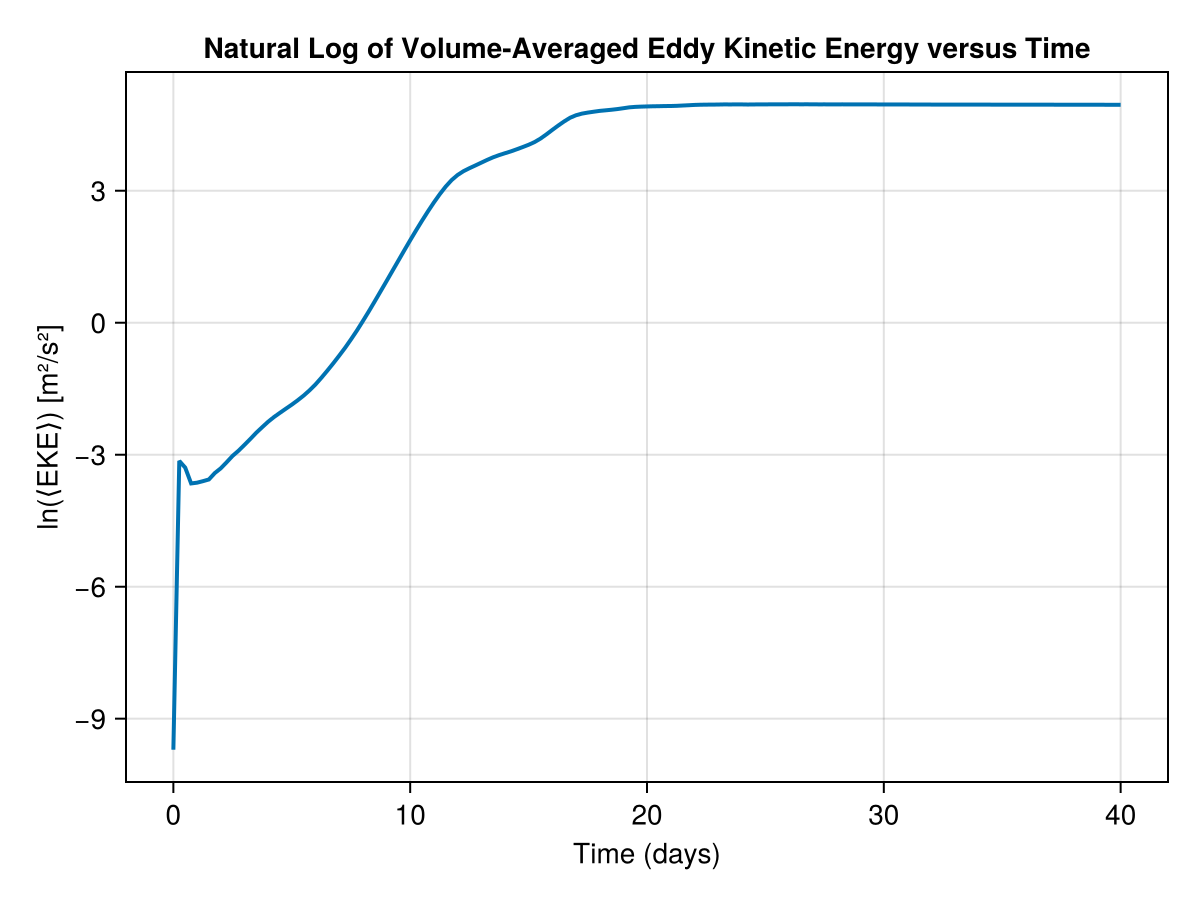

In [9]:
lnEKE = log.(EKE_avg)

fig_ln = Figure()
ax = Axis(fig_ln[1,1], 
            xlabel = "Time (days)", 
            ylabel = "ln(⟨EKE⟩) [m²/s²]", 
            title = "Natural Log of Volume-Averaged Eddy Kinetic Energy versus Time")

lines!(ax, time .* sec_2_day, lnEKE, linewidth=2)

fig_ln

### Lets compare this to linear theory

We will linear fit the rapid exponential growth phase of the EKE plot from days 10-14 ish

The linear theory predicts that velocity grows as : $\mathbf{v} \propto e^{\sigma t}$
therefore, $ EKE \propto e^{2 \sigma t} $

$\sigma_{theory} \sim 0.3 \frac{f_0}{NH} U $ so we want to see how close we can get to this value

In [10]:
#choose our linear fit window 

println("Start time = $(round(time[33] * sec_2_day; digits=1)) day")
println("End time = $(round(time[69] * sec_2_day; digits=1)) day")

#okay these r good

inds = 33:69
t_fit = time[inds] .* sec_2_day;
y_fit = lnEKE[inds]

#linear least squares fit
X = [ones(length(t_fit)) t_fit]
coeffs = X \ y_fit
a = coeffs[1]
slope = coeffs[2]
two_sigma = slope
σ = two_sigma / 2 #units 1/day

τ = 1 / σ

σ_theory = (0.3 * (f_0 / (N*H)) * U_shear) / sec_2_day #units 1/day
pct_diff = 100.0 * (σ - σ_theory) / σ_theory

println("Fitted slope (2σ) = $(two_sigma) [1/s]")
println("σ = $(round(σ, sigdigits=4)) day^-1")
println("e-folding time τ = $(round(τ; digits=3)) days")
println("Eady theory : σ_theory = $(round(σ_theory; sigdigits=4)) day^-1")
println("Percent difference (sim - theory)/theory = $(round(pct_diff;digits=2)) %")

Start time = 8.0 day
End time = 17.0 day
Fitted slope (2σ) = 0.48080362736100746 [1/s]
σ = 0.2404 day^-1
e-folding time τ = 4.16 days
Eady theory : σ_theory = 0.648 day^-1
Percent difference (sim - theory)/theory = -62.9 %


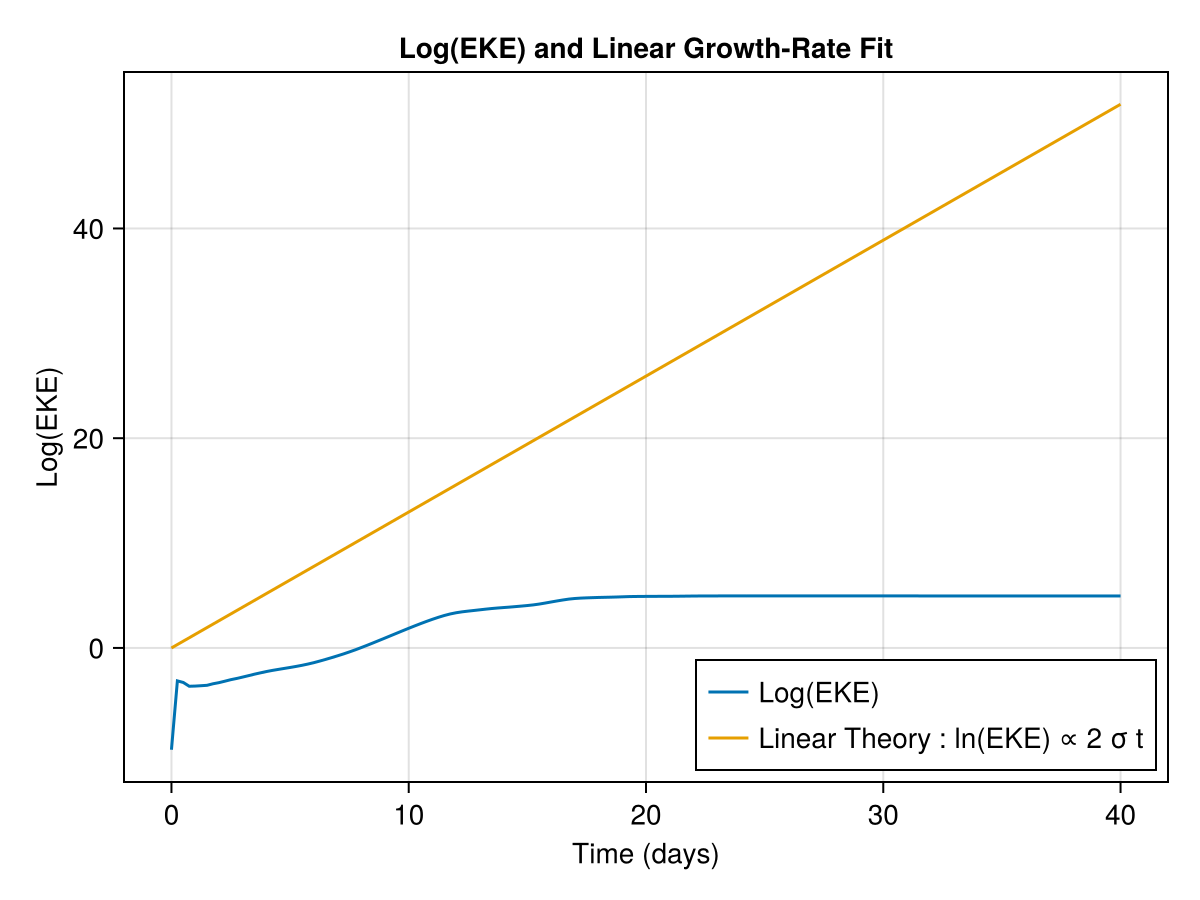

In [14]:
fig2 = Figure()
ax = Axis(fig2[1,1], title="Log(EKE) and Linear Growth-Rate Fit",
            xlabel = "Time (days)", ylabel = "Log(EKE)")
lines!(ax, time * sec_2_day, lnEKE, label="Log(EKE)")
# lines!(ax, t_fit, a .+ slope .* t_fit, 
#         linewidth = 2, 
#         linestyle = :dash, 
#         color = :red, 
#         label = "linear fit")
lines!(ax, time * sec_2_day, (2 * σ_theory * time * sec_2_day), label="Linear Theory : ln(EKE) ∝ 2 σ t")
axislegend(ax, position = :rb)

fig2


add a line that plots the theory of eke \sim 2 sigma t

In [29]:
#animation function

function animate_eady(filepath, animationpath)
#animation 
    ds = NCDataset(string(filepath))

    sec_2_day = (1/24) * (1/60) * (1/60)

    b = ds["b"][:,:,:,:]
    ζ = ds["ζ"][:,:,:,:]
    x = ds["x_caa"][:]
    y = ds["y_aca"][:]
    z = ds["z_aac"][:]
    time = ds["time"][:] .* sec_2_day

    Nx = ds.attrib["Nx"]
    Ny = ds.attrib["Ny"]
    Nz = ds.attrib["Nz"]

    @info "Making an animation from saved data..."

    n = Observable(1)

    title_b = @lift @sprintf("buoyancy [m/s²] in the yz plane at t=%.2f days", time[$n])
    title_v = @lift @sprintf("vorticity [1/s] in the xy plane at t=%.2f days", time[$n])

    bₙ = @lift b[Int(Nx/2), :, :, $n]
    ζₙ = @lift ζ[:, :, Int(Nz/2), $n]

    H = ds.attrib["H"]
    Lx = ds.attrib["Lx"]
    Ly = ds.attrib["Ly"]

    axis_kwargs = (xlabel = "y", 
                    ylabel= "z", 
                    limits = ((0, Ly), (-H, 0)),
                    titlesize = 20)

    fig = Figure(size = (800,600))

    ax_b = Axis(fig[1,1], title = title_b)
    b_lims = (-maximum(b), maximum(b))
    hm_b = heatmap!(ax_b, y, z, bₙ; colorrange = b_lims, colormap = :balance)
    Colorbar(fig[1,2], hm_b, label="b [m/s²]")

    ax_ζ = Axis(fig[2,1], title = title_v)
    ζ_lims = (-maximum(ζ), maximum(ζ))
    hm_ζ = heatmap!(ax_ζ, x, y, ζₙ; colorrange = ζ_lims, colormap = :curl)
    Colorbar(fig[2, 2], hm_ζ, label= "ζ [1/s]")

    frames = 1:length(time)
    record(fig, animationpath, frames, framerate=8) do i 
        n[] = i
    end


end

animate_eady (generic function with 1 method)

In [15]:
ds = NCDataset("/Users/hfdrake/Documents/GFD_Fall25/output/buoy_vort40day.nc")

sec_2_day = 1/86400
time = ds["time"][:] .* sec_2_day

x = ds["x_caa"][:]
y = ds["y_aca"][:]
z = ds["z_aac"][:]

Nx = ds.attrib["Nx"]
Ny = ds.attrib["Ny"]
Nz = ds.attrib["Nz"]

H = ds.attrib["H"]
Ly = ds.attrib["Ly"]

center_x = Int(Nx ÷ 2)
center_z = Int(Nz ÷ 2)

# --- Read first-frame slices (for initializing the plot) ---
b0 = ds["b"][center_x, :, :, 1]
ζ0 = ds["ζ"][:, :, center_z, 1]

fig = Figure(size = (800,600))

ax_b = Axis(fig[1,1], title = "buoyancy")
hm_b = heatmap!(ax_b, y, z, b0; colormap=:balance)
Colorbar(fig[1,2], hm_b, label = "b [m/s²]")

ax_ζ = Axis(fig[2,1], title = "vorticity")
hm_ζ = heatmap!(ax_ζ, x, y, ζ0; colormap=:curl, colorrange=(-2.5e-4, 2.5e-4))
Colorbar(fig[2, 2], hm_ζ, label= "ζ [1/s]")

frames = 1:length(time)

record(fig, "/Users/hfdrake/Documents/GFD_Fall25/eady_fast.mp4", frames, framerate=8) do i
    hm_b[3] = ds["b"][center_x, :, :, i]       # update data
    hm_ζ[3] = ds["ζ"][:, :, center_z, i]

    ax_b.title = @sprintf("buoyancy t = %.2f days", time[i])
    ax_ζ.title = @sprintf("vorticity t = %.2f days", time[i])
end


"/Users/hfdrake/Documents/GFD_Fall25/eady_fast.mp4"